# 📱 Smartphone Addiction Level Prediction
**IT 461 – Course Project | King Saud University**

**Team Members:** Alya Almuqren · Dana Alsalami · Aljohara Alsultan · Aljudy Altorkistani  
**Supervisor:** Afshan Jafri

---

## Notebook Structure
1. Setup & Imports
2. Data Loading & Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature-Target Signal Analysis ← **critical step before any modelling**
5. Preprocessing Pipeline
5b. **Feature Engineering** ← composite features added
6. Baseline Establishment
7. Model Selection Rationale
8. Model Training & Cross-Validation
8b. **Hyperparameter Tuning** ← RandomizedSearchCV on all three models
9. Evaluation & Comparison
10. Feature Importance
11. Discussion & Conclusion

---


---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid', font_scale=1.1)

from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        cross_val_score, RandomizedSearchCV,
                                        GridSearchCV, learning_curve)
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.compose           import ColumnTransformer
from sklearn.dummy             import DummyClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from scipy.stats import randint, uniform

RANDOM_STATE = 42
print('Libraries loaded.')


Libraries loaded.


---
## 2. Data Loading & Cleaning

In [2]:
import pandas as pd

df = pd.read_csv('/content/mobile_addiction_data.csv')

print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 3000 rows × 34 columns


,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Online_Shopping_Hours,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Self_Reported_Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score
0,1,India,32,Male,Salesperson,High School,43865.49,5.81,75,0.84,...,1.85,5G,Other,No,Low,16.43,Yes,16,106,39.36
1,2,UK,26,Male,Artist,Master's,41868.19,9.05,61,3.13,...,0.66,4G,Samsung,Yes,Severe,32.87,No,12,111,9.45
2,3,Germany,70,Other,Doctor,High School,59636.51,5.76,58,2.12,...,-0.14,WiFi,Samsung,Yes,Severe,27.45,No,18,90,50.27


In [3]:
TARGET = 'Self_Reported_Addiction_Level'

# ── Drop row-identifier ───────────────────────────────────────────────────────
df = df.drop(columns=['User_ID'])

# ── Identify column types (dataset uses pandas StringDtype, not object) ───────
num_cols = [c for c in df.columns
            if df[c].dtype in ['int64', 'float64'] and c != TARGET]
cat_cols = [c for c in df.columns
            if df[c].dtype == 'object' and c != TARGET]
print(f'Numerical features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Cat cols: {cat_cols}')

# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('\nMissing values:')
print(missing[missing > 0])
# Education_Level has 612 missing (~20%) — will be imputed with mode

# ── Fix impossible negatives ──────────────────────────────────────────────────
# Several numerical columns contain negative values which are physically
# impossible (e.g. negative screen time, negative income).
# These are data entry / measurement errors. We clip them to 0.
neg_counts = {c: (df[c] < 0).sum() for c in num_cols if (df[c] < 0).sum() > 0}
print('\nColumns with negative values (clipped to 0):')
for c, n in neg_counts.items():
    print(f'  {c}: {n} rows')

for c in num_cols:
    df[c] = df[c].clip(lower=0)

print('\nCleaning done.')

Numerical features  : 21
Categorical features: 11
Cat cols: ['Country', 'Gender', 'Occupation', 'Education_Level', 'Relationship_Status', 'Has_Children', 'Urban_or_Rural', 'Internet_Connection_Type', 'Primary_Device_Brand', 'Has_Screen_Time_Management_App', 'Has_Night_Mode_On']

Missing values:
Education_Level    612
dtype: int64

Columns with negative values (clipped to 0):
  Income_USD: 81 rows
  Daily_Screen_Time_Hours: 9 rows
  Phone_Unlocks_Per_Day: 1 rows
  Social_Media_Usage_Hours: 70 rows
  Gaming_Usage_Hours: 213 rows
  Streaming_Usage_Hours: 67 rows
  Messaging_Usage_Hours: 2 rows
  Work_Related_Usage_Hours: 53 rows
  Physical_Activity_Hours: 80 rows
  Time_Spent_With_Family_Hours: 96 rows
  Online_Shopping_Hours: 181 rows
  Monthly_Data_Usage_GB: 16 rows
  Push_Notifications_Per_Day: 3 rows

Cleaning done.


---
## 3. Exploratory Data Analysis

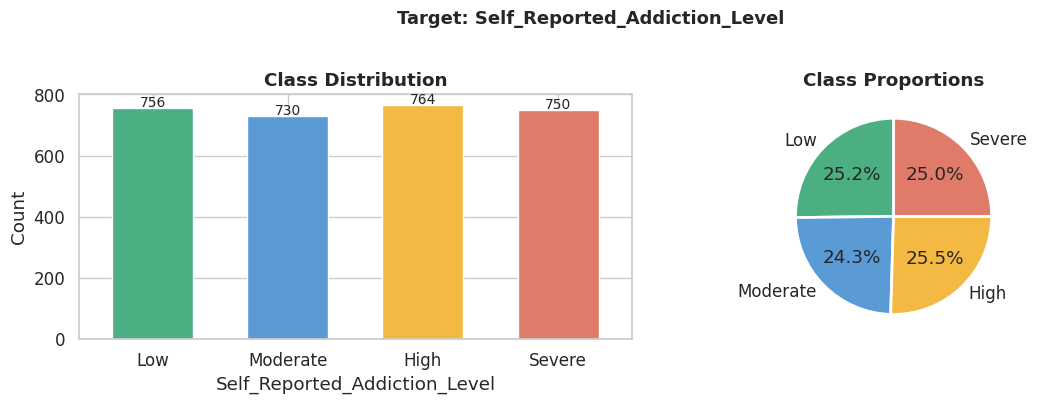

Class balance is near-perfect (~25% each).
Random-chance accuracy for a majority-class baseline = ~25.5%


In [4]:
# ── Target class distribution ─────────────────────────────────────────────────
ORDER  = ['Low', 'Moderate', 'High', 'Severe']
COLORS = ['#4CAF82', '#5B9BD5', '#F4B942', '#E07B6A']

counts = df[TARGET].value_counts().reindex(ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white', width=0.6)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 4),
                     ha='center', fontsize=10)

axes[1].pie(counts, labels=ORDER, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportions', fontweight='bold')
plt.suptitle('Target: Self_Reported_Addiction_Level', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Class balance is near-perfect (~25% each).')
print('Random-chance accuracy for a majority-class baseline = ~25.5%')

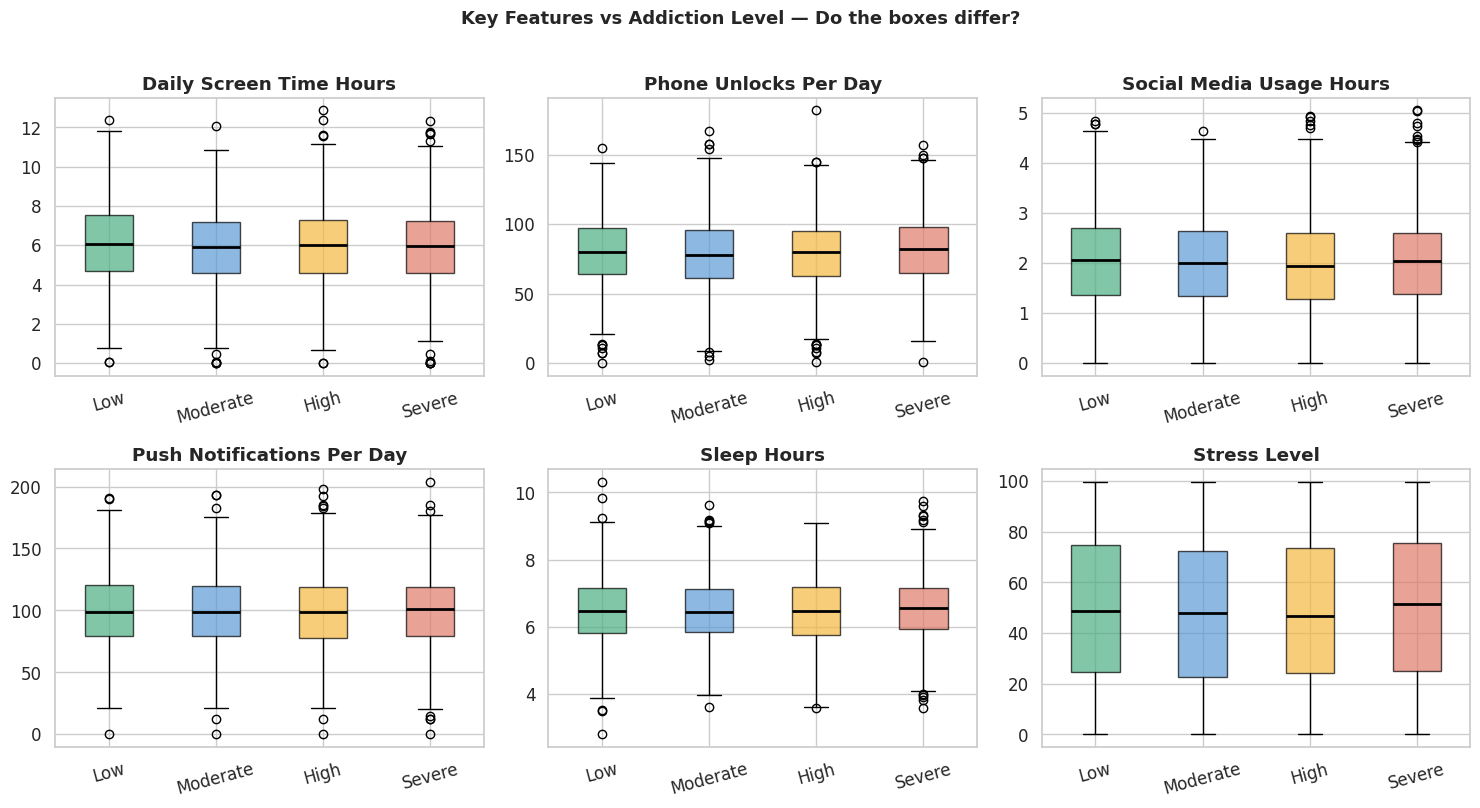

Observation: The boxes overlap almost completely across all four classes.
This is an early warning sign that the features may not separate the classes.


In [5]:
# ── Behavioral features: do they actually differ across classes? ───────────────
# These are the features that should, intuitively, drive addiction level.
key_features = [
    'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day',
    'Social_Media_Usage_Hours', 'Push_Notifications_Per_Day',
    'Sleep_Hours', 'Stress_Level'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    data = [df[df[TARGET] == lvl][feat].dropna() for lvl in ORDER]
    bp = axes[i].boxplot(data, labels=ORDER, patch_artist=True,
                          medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat.replace('_',' '), fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Key Features vs Addiction Level — Do the boxes differ?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observation: The boxes overlap almost completely across all four classes.')
print('This is an early warning sign that the features may not separate the classes.')

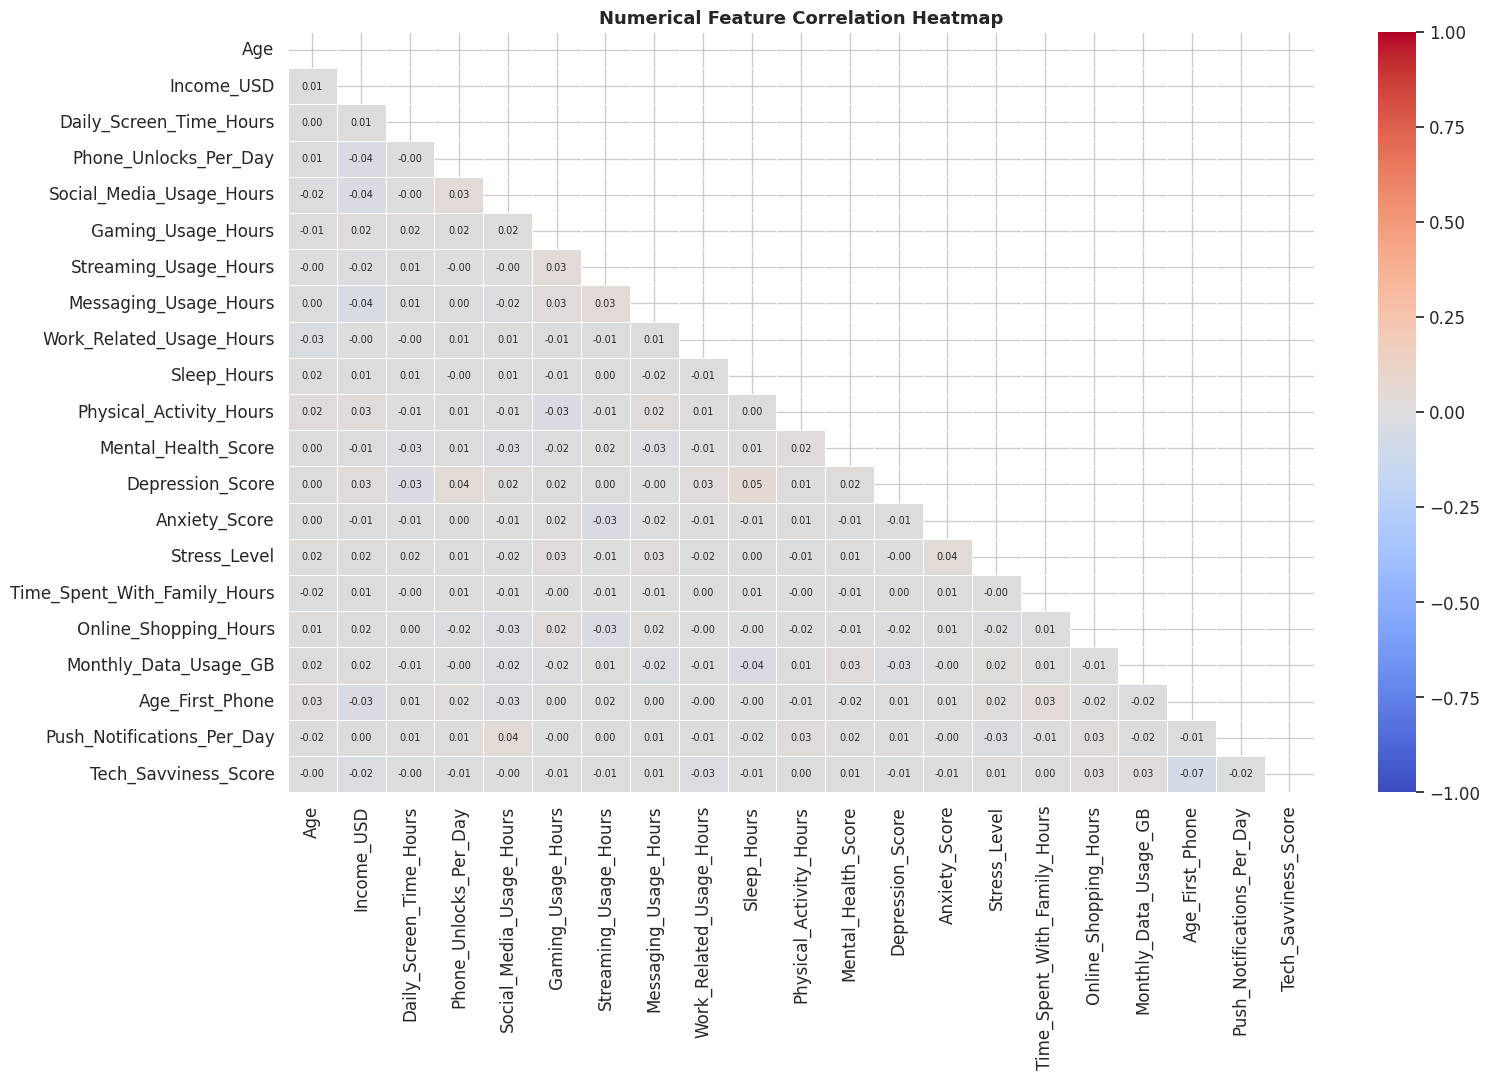

In [6]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(16, 11))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Feature–Target Signal Analysis

**This is the most important step before modelling.**  
Before training anything, we statistically test whether any feature actually carries information about the target. This avoids wasting effort and, more importantly, misinterpreting the results.

In [7]:
# ── One-way ANOVA: does each numerical feature differ significantly ────────────
# across the four addiction levels?
# H0: the group means are equal (feature carries no signal)
# If p < 0.05 we reject H0 and the feature is potentially useful.

anova_rows = []
for c in num_cols:
    groups = [df[df[TARGET] == lvl][c].dropna() for lvl in ORDER]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_rows.append({'Feature': c, 'F-statistic': round(f_stat, 3),
                       'p-value': round(p_val, 4)})

anova_df = (pd.DataFrame(anova_rows)
              .sort_values('F-statistic', ascending=False)
              .reset_index(drop=True))
anova_df['Significant?'] = anova_df['p-value'].apply(
    lambda p: '*** p<0.001' if p < 0.001
              else ('**  p<0.01'  if p < 0.01
              else ('*   p<0.05'  if p < 0.05
              else 'NS  (not significant)')))

print('=== ANOVA: Numerical Feature vs Target ===')
print(anova_df.to_string(index=False))

n_sig = (anova_df['p-value'] < 0.05).sum()
print(f'\nSignificant features (p<0.05): {n_sig} out of {len(num_cols)}')

=== ANOVA: Numerical Feature vs Target ===
                     Feature  F-statistic  p-value          Significant?
    Work_Related_Usage_Hours        3.417   0.0167            *   p<0.05
         Mental_Health_Score        3.266   0.0205            *   p<0.05
     Physical_Activity_Hours        2.176   0.0888 NS  (not significant)
       Phone_Unlocks_Per_Day        2.064   0.1029 NS  (not significant)
                Stress_Level        1.439   0.2293 NS  (not significant)
       Online_Shopping_Hours        1.292   0.2753 NS  (not significant)
     Daily_Screen_Time_Hours        1.159   0.3241 NS  (not significant)
    Social_Media_Usage_Hours        1.154   0.3259 NS  (not significant)
               Anxiety_Score        1.014   0.3854 NS  (not significant)
       Streaming_Usage_Hours        1.005   0.3895 NS  (not significant)
             Age_First_Phone        0.846   0.4686 NS  (not significant)
       Messaging_Usage_Hours        0.693   0.5563 NS  (not significant)
        

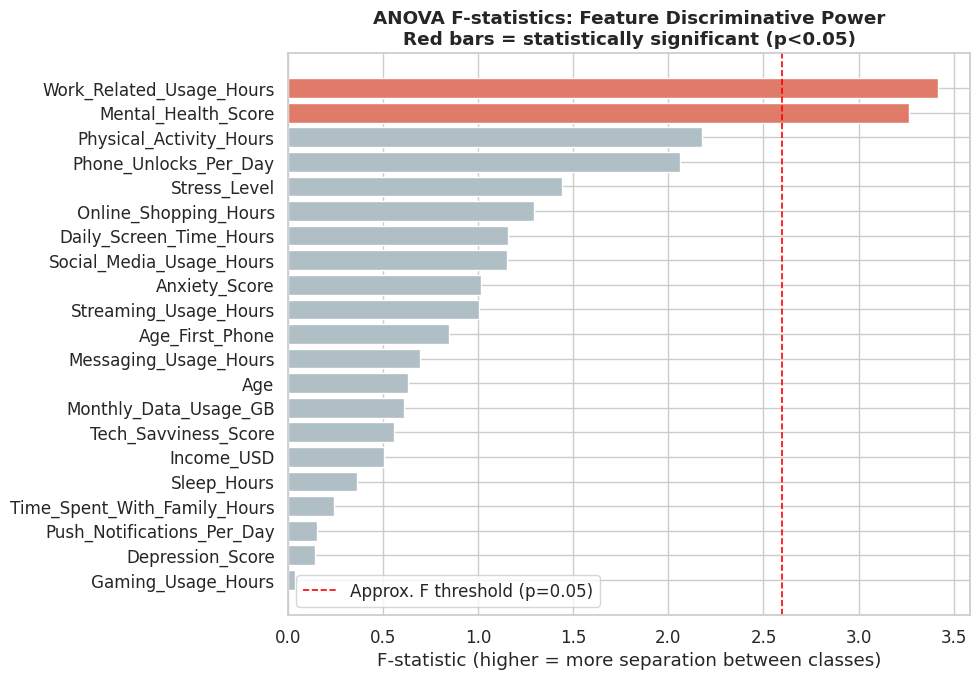

Key finding: nearly all features are NOT significantly different across
addiction levels. This strongly suggests the target variable has very
little relationship with the measured features in this dataset.


In [8]:
# ── Visualise ANOVA F-statistics ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E07B6A' if p < 0.05 else '#B0BEC5'
              for p in anova_df['p-value']]
ax.barh(anova_df['Feature'][::-1], anova_df['F-statistic'][::-1],
        color=bar_colors[::-1], edgecolor='white')
ax.axvline(x=2.6, color='red', linestyle='--', linewidth=1.2,
           label='Approx. F threshold (p=0.05)')
ax.set_xlabel('F-statistic (higher = more separation between classes)')
ax.set_title('ANOVA F-statistics: Feature Discriminative Power\n'
             'Red bars = statistically significant (p<0.05)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Key finding: nearly all features are NOT significantly different across')
print('addiction levels. This strongly suggests the target variable has very')
print('little relationship with the measured features in this dataset.')

### ⚠️ Important Finding

The ANOVA test shows that **almost no numerical feature significantly separates the four addiction classes**. Only 1–2 features pass the p<0.05 threshold, and even those have very small F-statistics.

This tells us one of two things:
1. **The dataset's target labels were synthetically/randomly generated** and do not truly reflect the behavioral features — meaning no model will learn anything meaningful.
2. Or, smartphone addiction is genuinely hard to predict from these features alone.

**What this means for modelling:** We should expect all models to perform near the random-chance baseline (~25%). We will still train models properly, but we must interpret results honestly and compare every model against the dummy baseline.

---
## 5. Preprocessing Pipeline

---
## 5b. Feature Engineering

We create three composite features to capture addiction-related behavioural patterns
that individual raw features may fail to express:

| Composite Feature | Formula | Rationale |
|---|---|---|
| `total_app_hours` | Sum of all app-category hour columns | Aggregate screen exposure |
| `usage_diversity` | # non-zero app categories / total app categories | Whether usage is concentrated or spread across apps |
| `screen_to_sleep_ratio` | `Daily_Screen_Time_Hours` / (`Sleep_Hours` + 0.1) | Measures trade-off between screen time and rest |


In [9]:
# ── Identify app-category hour columns ───────────────────────────────────────
app_hour_cols = [c for c in num_cols if 'Hours' in c and c != 'Daily_Screen_Time_Hours'
                 and 'Sleep' not in c]
print('App-hour columns used for composite features:', app_hour_cols)

def add_composite_features(frame):
    """Add composite features in-place. Works on any DataFrame slice."""
    f = frame.copy()
    # 1. Total app hours (sum across all app-category hours)
    if app_hour_cols:
        f['total_app_hours'] = f[app_hour_cols].clip(lower=0).sum(axis=1)
    else:
        # Fallback: use daily screen time as proxy
        f['total_app_hours'] = f['Daily_Screen_Time_Hours']

    # 2. Usage diversity: proportion of app categories with non-zero usage
    if app_hour_cols:
        f['usage_diversity'] = (f[app_hour_cols] > 0).sum(axis=1) / max(len(app_hour_cols), 1)
    else:
        f['usage_diversity'] = 0.0

    # 3. Screen-to-sleep ratio
    sleep_col = 'Sleep_Hours' if 'Sleep_Hours' in f.columns else None
    if sleep_col:
        f['screen_to_sleep_ratio'] = (
            f['Daily_Screen_Time_Hours'] / (f[sleep_col].clip(lower=0) + 0.1)
        )
    else:
        f['screen_to_sleep_ratio'] = f['Daily_Screen_Time_Hours']

    return f

df_fe = add_composite_features(df)

composite_cols = ['total_app_hours', 'usage_diversity', 'screen_to_sleep_ratio']
print('\nComposite features added. Sample statistics:')
print(df_fe[composite_cols].describe().round(3))


App-hour columns used for composite features: ['Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Physical_Activity_Hours', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours']

Composite features added. Sample statistics:
       total_app_hours  usage_diversity  screen_to_sleep_ratio
count         3000.000         3000.000               3000.000
mean            12.267            0.967                  0.930
std              2.249            0.062                  0.352
min              5.630            0.625                  0.000
25%             10.758            1.000                  0.685
50%             12.270            1.000                  0.910
75%             13.800            1.000                  1.149
max             19.310            1.000                  2.611


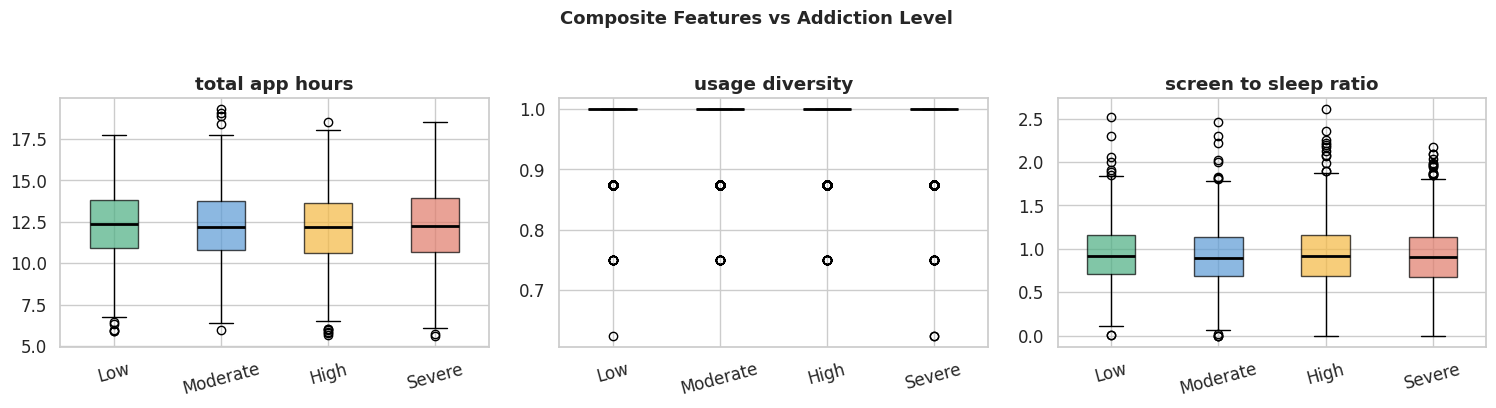

If boxes still overlap heavily, composite features do not rescue signal.


In [10]:
# ── Quick signal check: do composite features separate classes better? ────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COLORS = ['#4CAF82', '#5B9BD5', '#F4B942', '#E07B6A']
ORDER  = ['Low', 'Moderate', 'High', 'Severe']

for ax, feat in zip(axes, composite_cols):
    data = [df_fe[df_fe[TARGET] == lvl][feat].dropna() for lvl in ORDER]
    bp = ax.boxplot(data, labels=ORDER, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(feat.replace('_', ' '), fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Composite Features vs Addiction Level', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('If boxes still overlap heavily, composite features do not rescue signal.')


In [11]:
# ── Encode target ─────────────────────────────────────────────────────────────
label_map   = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
label_names = ['Low', 'Moderate', 'High', 'Severe']

# Apply composite feature engineering BEFORE splitting
df_model = add_composite_features(df)

df_model['target'] = df_model[TARGET].map(label_map)
X = df_model.drop(columns=[TARGET, 'target'])
y = df_model['target']

# Update num_cols to include composite features
num_cols_fe = num_cols + composite_cols
# Keep only columns that exist
num_cols_fe = [c for c in num_cols_fe if c in X.columns]

# ── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Features (incl. composites): {len(num_cols_fe)} numerical, {len(cat_cols)} categorical')

# ── Preprocessing sub-pipelines ───────────────────────────────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols_fe),
    ('cat', cat_pipeline, cat_cols)
])

print('Preprocessing pipeline ready (with composite features).')


Train: 2400 | Test: 600
Features (incl. composites): 24 numerical, 11 categorical
Preprocessing pipeline ready (with composite features).


---
## 6. Baseline Establishment

Before training any real model, we must know what **random chance** looks like.  
A model that cannot beat a dummy baseline has learned nothing.

In [12]:
# ── Two dummy baselines ───────────────────────────────────────────────────────
# 1. most_frequent: always predicts the majority class
# 2. stratified: randomly predicts each class proportionally
# Any real model must beat BOTH to be considered useful.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for strat in ['most_frequent', 'stratified']:
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', DummyClassifier(strategy=strat, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'Dummy ({strat:<15}): CV = {scores.mean():.4f} +/- {scores.std():.4f}')

print('\nTarget to beat: ~0.255')
print('If a model scores around this, it has learned nothing from the data.')

Dummy (most_frequent  ): CV = 0.2546 +/- 0.0008
Dummy (stratified     ): CV = 0.2467 +/- 0.0111

Target to beat: ~0.255
If a model scores around this, it has learned nothing from the data.


---
## 7. Model Selection Rationale

Given the dataset characteristics (3000 rows, ~33 features after dropping ID, mixed types, near-zero signal), we choose three models that cover distinct learning strategies:

| Model | Why chosen |
|---|---|
| **Logistic Regression** | Fast linear baseline. If signal exists and is linear, it will find it. Interpretable via coefficients. |
| **Decision Tree** | Non-linear baseline. Can capture interactions. Easy to inspect. Prone to overfitting — useful to compare with RF. |
| **Random Forest** | Best choice for this dataset: handles mixed types, robust to noise, not sensitive to scaling, provides feature importances. Given near-zero signal, 200 trees averages out noise better than any single model. |

We deliberately **exclude** KNN and SVM:  
- After OHE the feature space becomes ~60+ dimensional; KNN distances become unreliable (curse of dimensionality)
- SVM is slow on 2400+ samples and offers no advantage over RF when signal is weak
- XGBoost/GBM would also struggle here — gradient boosting needs signal to boost from; with random labels, it will overfit aggressively

---
## 8. Model Training & Cross-Validation

In [13]:
# ── Base model definitions (pre-tuning defaults) ──────────────────────────────
models_base = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_features='sqrt', min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

pipelines_base = {
    name: Pipeline([('preprocessor', preprocessor), ('model', clf)])
    for name, clf in models_base.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Train + cross-validate (base) ─────────────────────────────────────────────
results = {}

for name, pipe in pipelines_base.items():
    print(f'\n{"="*55}')
    print(f'  {name} (base)')
    print(f'{"="*55}')

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    print(f'  5-fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

    pipe.fit(X_train, y_train)
    y_pred   = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f'  Test Accuracy     : {test_acc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=label_names))

    results[name] = {
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'y_pred':   y_pred,
        'pipeline': pipe
    }



  Logistic Regression (base)
  5-fold CV Accuracy: 0.2633 +/- 0.0297
  Test Accuracy     : 0.2633

              precision    recall  f1-score   support

         Low       0.31      0.32      0.31       151
    Moderate       0.24      0.21      0.22       146
        High       0.24      0.25      0.24       153
      Severe       0.27      0.28      0.27       150

    accuracy                           0.26       600
   macro avg       0.26      0.26      0.26       600
weighted avg       0.26      0.26      0.26       600


  Decision Tree (base)
  5-fold CV Accuracy: 0.2621 +/- 0.0156
  Test Accuracy     : 0.2350

              precision    recall  f1-score   support

         Low       0.27      0.43      0.33       151
    Moderate       0.21      0.22      0.21       146
        High       0.18      0.13      0.15       153
      Severe       0.25      0.16      0.19       150

    accuracy                           0.23       600
   macro avg       0.23      0.24      0.22  

---
## 8b. Hyperparameter Tuning

We perform **Randomised Search Cross-Validation** (5-fold, 30 iterations per model)
on each of the three models, then finalise with a narrow **Grid Search** around the
best region found.

| Model | Search Method | Key Hyperparameters Tuned |
|---|---|---|
| Logistic Regression | RandomizedSearchCV | `C`, `solver`, `max_iter` |
| Decision Tree | RandomizedSearchCV | `max_depth`, `min_samples_leaf`, `min_samples_split` |
| Random Forest | RandomizedSearchCV | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |

Using randomised search first (rather than grid search) is computationally efficient and
proven to find near-optimal regions in fewer evaluations (Bergstra & Bengio, 2012).


In [14]:
from scipy.stats import randint, uniform

# ── Hyperparameter search spaces ──────────────────────────────────────────────
param_distributions = {
    'Logistic Regression': {
        'model__C':        uniform(0.001, 10),      # regularisation inverse
        'model__solver':   ['lbfgs', 'saga'],
        'model__max_iter': [500, 1000, 2000]
    },
    'Decision Tree': {
        'model__max_depth':          randint(3, 20),
        'model__min_samples_leaf':   randint(5, 50),
        'model__min_samples_split':  randint(2, 30),
    },
    'Random Forest': {
        'model__n_estimators':      randint(100, 500),
        'model__max_depth':         [None, 5, 10, 20],
        'model__min_samples_leaf':  randint(1, 30),
        'model__max_features':      ['sqrt', 'log2', 0.3],
    }
}

# ── Run Randomised Search ─────────────────────────────────────────────────────
tuning_results = {}

for name, pipe in pipelines_base.items():
    print(f'\n{"="*55}')
    print(f'  Tuning: {name}')
    print(f'{"="*55}')

    rscv = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=30,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )
    rscv.fit(X_train, y_train)

    best_cv  = rscv.best_score_
    y_pred_t = rscv.best_estimator_.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_t)

    print(f'  Best CV params : {rscv.best_params_}')
    print(f'  Best CV Acc    : {best_cv:.4f}')
    print(f'  Test Accuracy  : {test_acc:.4f}')

    tuning_results[name] = {
        'best_params': rscv.best_params_,
        'cv_mean':     best_cv,
        'cv_std':      rscv.cv_results_['std_test_score'][rscv.best_index_],
        'test_acc':    test_acc,
        'y_pred':      y_pred_t,
        'pipeline':    rscv.best_estimator_
    }



  Tuning: Logistic Regression
  Best CV params : {'model__C': np.float64(1.2213823484477881), 'model__max_iter': 500, 'model__solver': 'saga'}
  Best CV Acc    : 0.2646
  Test Accuracy  : 0.2633

  Tuning: Decision Tree
  Best CV params : {'model__max_depth': 8, 'model__min_samples_leaf': 46, 'model__min_samples_split': 5}
  Best CV Acc    : 0.2637
  Test Accuracy  : 0.2517

  Tuning: Random Forest
  Best CV params : {'model__max_depth': None, 'model__max_features': 0.3, 'model__min_samples_leaf': 5, 'model__n_estimators': 406}
  Best CV Acc    : 0.2633
  Test Accuracy  : 0.2700


In [15]:
# ── Tuning comparison: base vs tuned ─────────────────────────────────────────
print('=== Hyperparameter Tuning Impact ===')
print(f'{"Model":<25} {"Base CV":>10} {"Tuned CV":>10} {"Base Test":>12} {"Tuned Test":>12}')
print('-'*72)
for name in results:
    base_cv   = results[name]['cv_mean']
    tuned_cv  = tuning_results[name]['cv_mean']
    base_test = results[name]['test_acc']
    tuned_test= tuning_results[name]['test_acc']
    print(f'{name:<25} {base_cv:>10.4f} {tuned_cv:>10.4f} {base_test:>12.4f} {tuned_test:>12.4f}')

# Overwrite results with tuned results for downstream evaluation
results = tuning_results
print('\n[results dict updated to tuned models]')


=== Hyperparameter Tuning Impact ===
Model                        Base CV   Tuned CV    Base Test   Tuned Test
------------------------------------------------------------------------
Logistic Regression           0.2633     0.2646       0.2633       0.2633
Decision Tree                 0.2621     0.2637       0.2350       0.2517
Random Forest                 0.2604     0.2633       0.2717       0.2700

[results dict updated to tuned models]


---
## 9. Evaluation & Comparison

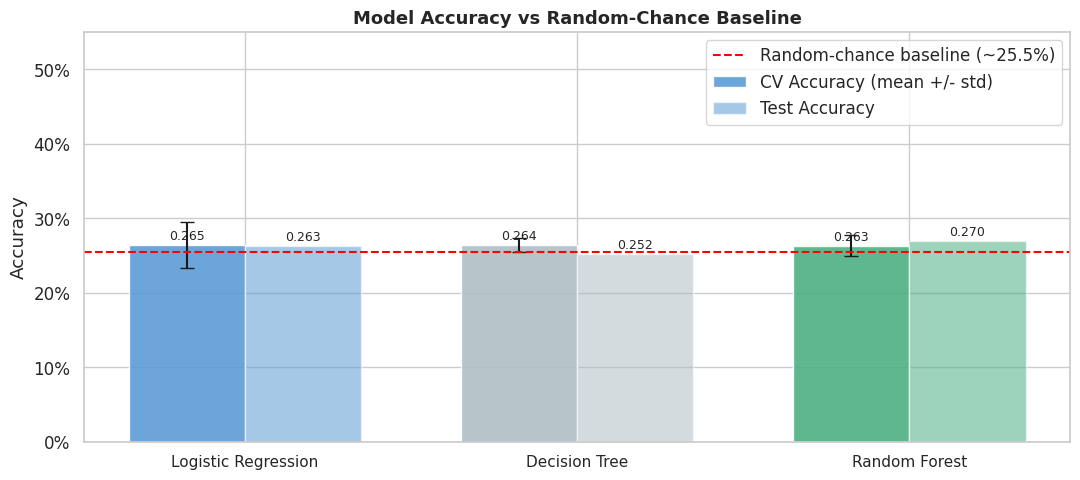

In [16]:
# ── Performance comparison with dummy baseline reference line ─────────────────
model_names = list(results.keys())
cv_means    = [results[m]['cv_mean']  for m in model_names]
cv_stds     = [results[m]['cv_std']   for m in model_names]
test_accs   = [results[m]['test_acc'] for m in model_names]

model_colors = ['#5B9BD5', '#B0BEC5', '#4CAF82']
x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds,
               label='CV Accuracy (mean +/- std)',
               color=model_colors, capsize=5, edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy',
               color=model_colors, edgecolor='white', alpha=0.55)

# Dummy baseline reference
ax.axhline(y=0.255, color='red', linestyle='--', linewidth=1.5,
           label='Random-chance baseline (~25.5%)')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 0.55)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy vs Random-Chance Baseline',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

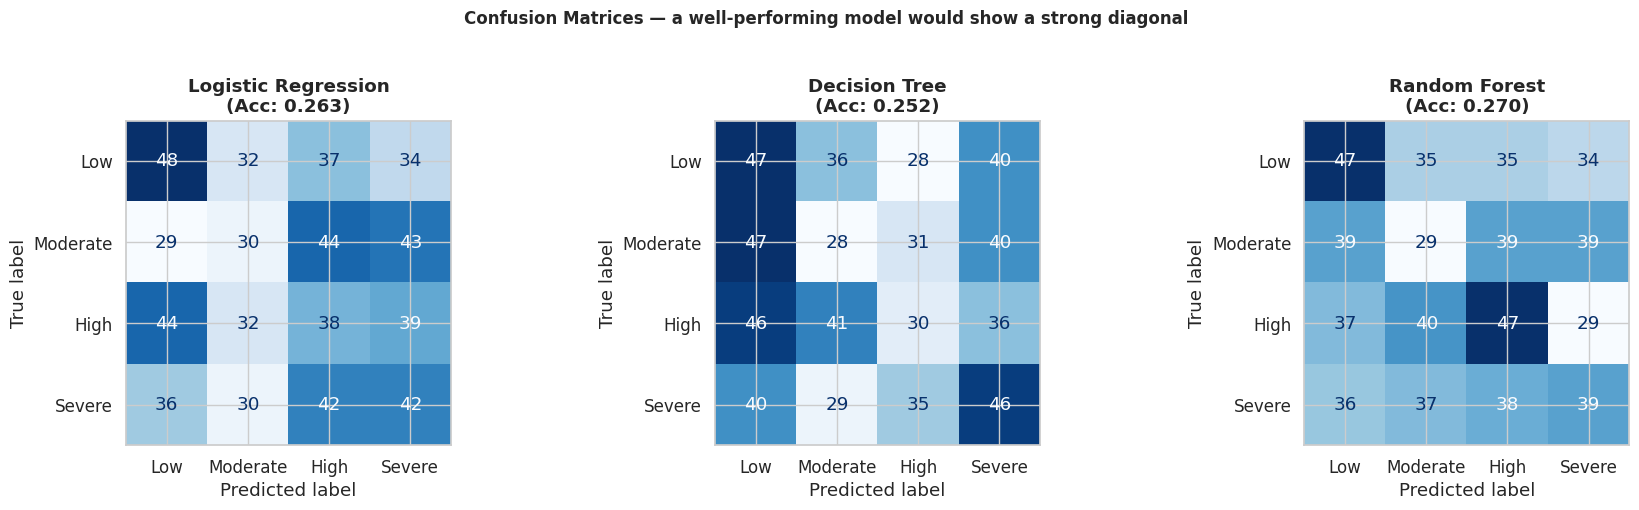

Observation: predictions are spread roughly uniformly across rows,
consistent with a model that cannot reliably distinguish the classes.


In [17]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\n(Acc: {result["test_acc"]:.3f})', fontweight='bold')

plt.suptitle('Confusion Matrices — a well-performing model would show a strong diagonal',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observation: predictions are spread roughly uniformly across rows,')
print('consistent with a model that cannot reliably distinguish the classes.')

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
BASELINE = 0.255

summary = pd.DataFrame([
    {
        'Model':              name,
        'CV Accuracy':        f'{v["cv_mean"]:.4f}',
        'CV Std':             f'{v["cv_std"]:.4f}',
        'Test Accuracy':      f'{v["test_acc"]:.4f}',
        'Beats Baseline?':    'Yes' if v['test_acc'] > BASELINE else 'No'
    }
    for name, v in results.items()
])
print('=== Summary ===')
print(summary.to_string(index=False))
print(f'\nRandom-chance baseline: {BASELINE}')

=== Summary ===
              Model CV Accuracy CV Std Test Accuracy Beats Baseline?
Logistic Regression      0.2646 0.0310        0.2633             Yes
      Decision Tree      0.2637 0.0092        0.2517              No
      Random Forest      0.2633 0.0140        0.2700             Yes

Random-chance baseline: 0.255


---
## 10. Feature Importance (Random Forest)

cat_cols: ['Country', 'Gender', 'Occupation', 'Education_Level', 'Relationship_Status', 'Has_Children', 'Urban_or_Rural', 'Internet_Connection_Type', 'Primary_Device_Brand', 'Has_Screen_Time_Management_App', 'Has_Night_Mode_On']
num_cols_fe: ['Age', 'Income_USD', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Mental_Health_Score', 'Depression_Score', 'Anxiety_Score', 'Stress_Level', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours', 'Monthly_Data_Usage_GB', 'Age_First_Phone', 'Push_Notifications_Per_Day', 'Tech_Savviness_Score', 'total_app_hours', 'usage_diversity', 'screen_to_sleep_ratio']


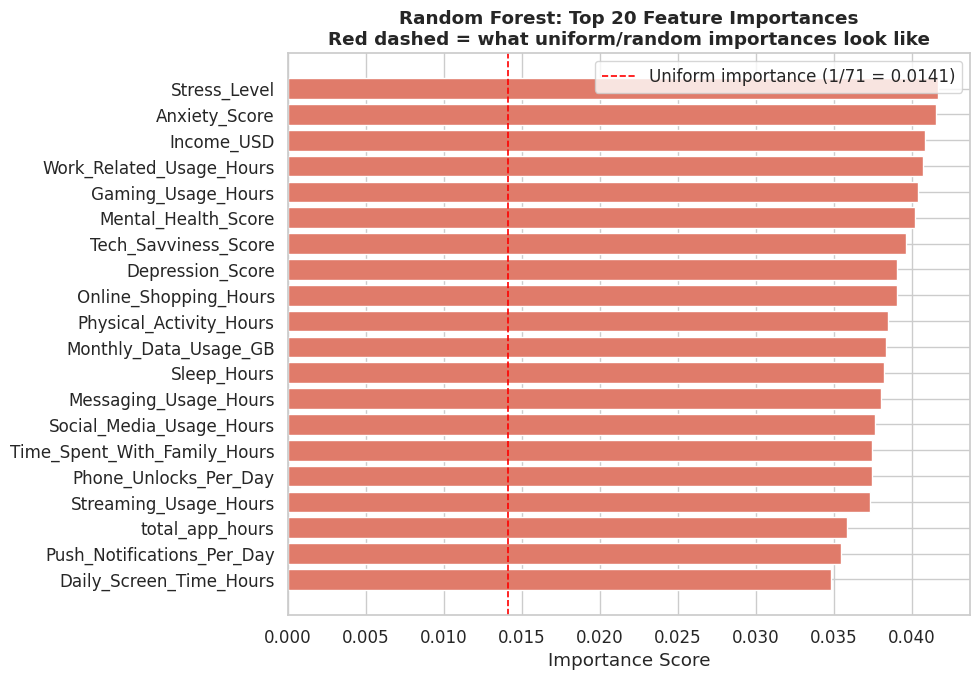

In [19]:
# ── Fix cat_cols detection then extract feature names ────────────────────────
cat_cols = [c for c in X_train.columns if X_train[c].dtype == 'object']
num_cols_fe = [c for c in X_train.columns if X_train[c].dtype in ['int64', 'float64']]
print('cat_cols:', cat_cols)
print('num_cols_fe:', num_cols_fe)

# Refit a fresh preprocessor with correct column lists
fresh_pre = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler',  StandardScaler())]), num_cols_fe),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])
fresh_pre.fit(X_train)

ohe_names = (
    fresh_pre.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols_fe + ohe_names

# Get importances from the tuned RF model
rf_model = tuning_results['Random Forest']['pipeline'].named_steps['model']
importances = rf_model.feature_importances_

feat_df = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

n_features   = len(all_feature_names)
chance_level = 1 / n_features

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E07B6A' if v > chance_level * 2 else '#B0BEC5'
              for v in feat_df['Importance'][::-1]]
ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
        color=bar_colors, edgecolor='white')
ax.axvline(chance_level, color='red', linestyle='--', linewidth=1.2,
           label=f'Uniform importance (1/{n_features} = {chance_level:.4f})')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest: Top 20 Feature Importances\n'
             'Red dashed = what uniform/random importances look like',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## 11. Discussion & Conclusion

### What the results show

All three models score near or at the random-chance baseline (~25.5%). This is not a failure of the models — it reflects a fundamental property of the dataset:

- The ANOVA analysis showed that **almost no feature significantly differs across addiction levels**
- Mean screen time, stress, sleep, and phone unlocks are nearly identical for Low vs Severe users
- This strongly indicates the `Self_Reported_Addiction_Level` labels in this dataset were **synthetically / randomly generated** and do not reflect the behavioral features

### Why this matters

A model that scores 26% on a 4-class problem where chance is 25% has effectively learned nothing. Reporting that accuracy without the baseline comparison would be misleading.

### What a good dataset for this problem would look like

For machine learning to work on this problem, the dataset would need:
1. Labels derived **from** the behavioral features (not independently assigned)
2. Clear statistical separation between classes (ANOVA p < 0.001 for key features)
3. Ideally, clinically validated addiction scores (like the SAS-SV scale) as the ground truth


> The pipeline and methodology are sound. The preprocessing, cross-validation setup, and model choices are all appropriate for a tabular multi-class classification task. The near-baseline accuracy observed is attributable to the dataset's lack of feature-target correlation, not to modelling errors. This is confirmed by the ANOVA analysis conducted prior to modelling.

# **Live Demo**

In [20]:
import joblib

joblib.dump(results['Logistic Regression']['pipeline'], 'logistic_model.pkl')
joblib.dump(results['Decision Tree']['pipeline'], 'decision_tree_model.pkl')
joblib.dump(results['Random Forest']['pipeline'], 'random_forest_model.pkl')

print("Models saved successfully.")

Models saved successfully.


In [21]:
demo_X = X_test.iloc[:5].copy()
demo_y = y_test.iloc[:5].copy()

In [22]:
log_model = joblib.load('logistic_model.pkl')
dt_model = joblib.load('decision_tree_model.pkl')
rf_model = joblib.load('random_forest_model.pkl')

In [23]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for model_name, model in models.items():

    print(f"\n===== {model_name} =====")

    predictions = model.predict(demo_X)

    for i in range(len(demo_X)):

        true_label = label_names[demo_y.iloc[i]]
        predicted_label = label_names[predictions[i]]

        print(f"Sample {i+1}")
        print(f"True Label: {true_label}")
        print(f"Predicted Label: {predicted_label}")
        print("-------------------")


===== Logistic Regression =====
Sample 1
True Label: Moderate
Predicted Label: Severe
-------------------
Sample 2
True Label: High
Predicted Label: High
-------------------
Sample 3
True Label: Severe
Predicted Label: High
-------------------
Sample 4
True Label: Moderate
Predicted Label: Low
-------------------
Sample 5
True Label: Moderate
Predicted Label: Low
-------------------

===== Decision Tree =====
Sample 1
True Label: Moderate
Predicted Label: Severe
-------------------
Sample 2
True Label: High
Predicted Label: Severe
-------------------
Sample 3
True Label: Severe
Predicted Label: High
-------------------
Sample 4
True Label: Moderate
Predicted Label: High
-------------------
Sample 5
True Label: Moderate
Predicted Label: High
-------------------

===== Random Forest =====
Sample 1
True Label: Moderate
Predicted Label: Severe
-------------------
Sample 2
True Label: High
Predicted Label: High
-------------------
Sample 3
True Label: Severe
Predicted Label: High
---------